### Compare cellchat results from separate zones

In [1]:
#remotes::install_github("jinworks/CellChat@88c2e13")

suppressPackageStartupMessages({
    library(CellChat)
    library(zellkonverter)
    library(SingleCellExperiment())
    library(ComplexHeatmap)
})



In [2]:
library(tidyr)
library(tibble)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand


The following object is masked from ‘package:igraph’:

    crossing



Attaching package: ‘tibble’


The following object is masked from ‘package:igraph’:

    as_data_frame




In [3]:
dist_out_dir <- "/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance"
dist_out_dir_cellchat <- "/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance/cellchat_zone"
plot_out_dir <- file.path(dist_out_dir_cellchat, "plots")

## Load cellchat results

In [4]:
cellchat =  readRDS(file.path(dist_out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_contact_10_popsize_FALSE.rds"))



## Plotting palettes


In [5]:
celltype_palette_mapped <- c('AT1'= '#ffff00',
 'AT2'= '#1ce6ff',
 'Club'= '#ff34ff',
 'Ciliated'= '#ff4a46',
 'SMC'= '#008941',
 'Col13a1+ fibroblast'= '#006fa6',
 'Col14a1+ fibroblast'= '#a30059',
 'Myofibroblast'= '#ffdbe5',
 'Pericyte 1'= '#7a4900',
 'Pericyte 2'= '#0000a6',
 'Mesothelial'= '#63ffac',
 'Cap'= '#b79762',
 'Cap-a'= '#004d43',
 'Art'= '#8fb0ff',
 'Vein'= '#997d87',
 'Lymph'= '#5a0007',
 'Mono'= '#809693',
 'Int Mf'= '#6a3a4c',
 'Alv Mf'= '#1b4400',
 'Neut'= '#4fc601',
 'cDC1'= '#3b5dff',
 'Ccr7- cDC2'= '#4a3b53',
 'Ccr7+ cDC2'= '#ff2f80',
 'B cell'= '#61615a',
 'Plasmablast'= '#ba0900',
 'NK cell'= '#6b7900',
 'gd T cell'= '#00c2a0',
 'ILC2'= '#ffaa92',
 'CD8 naive'= '#ff90c9',
 'CD8 act'= '#b903aa',
 'CD4 naive'= '#d16100',
    'CD4 act (parenchyma)'='#006400', 
    'CD4 act (adventitia)'='#98FB98', 
    'CD4 act (TLS)'='#BDB76B' 
)

## Run netAnalysis_computeCentrality

In [6]:
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP")

## Plotting

In [15]:
# First adjust the cell label order
label_df <- read.csv("/home/workspace/spatial_tls_manuscript/inputs/20250519_mouse_lung_label_mapping_ordered.csv")

# Get the current labels in the CellChat object
cellchat_labels <- unique(cellchat@idents)

# Keep only labels that are in the cellchat object
ordered_labels <- label_df$label_fine[label_df$label_fine %in% cellchat_labels]

# Optional: Append custom labels (if needed)
extra_labels <- c('CD4 act (parenchyma)', 'CD4 act (adventitia)', 'CD4 act (TLS)')
cell_order <- c(as.character(ordered_labels), extra_labels)
cell_order <- rev(cell_order)

# Update the CellChat object with new label order
cellchat@meta$labels <- factor(cellchat@idents, levels = cell_order)
cellchat <- updateClusterLabels(cellchat, new.order = cell_order)

Only reorder cell groups but do not rename cell groups!

Reorder cell groups! 



The cell group order before reordering is  AT1 AT2 Alv Mf Art B cell CD4 act (TLS) CD4 act (adventitia) CD4 act (parenchyma) CD4 naive CD8 act CD8 naive Cap Cap-a Ccr7+ cDC2 Ccr7- cDC2 Ciliated Club Col13a1+ fibroblast Col14a1+ fibroblast ILC2 Int Mf Lymph Mesothelial Mono Myofibroblast NK cell Neut Pericyte 1 Pericyte 2 Plasmablast SMC Vein cDC1 gd T cell 
The cell group order after reordering is  CD4 act (TLS) CD4 act (adventitia) CD4 act (parenchyma) CD4 naive CD8 act CD8 naive ILC2 gd T cell NK cell Plasmablast B cell Ccr7+ cDC2 Ccr7- cDC2 cDC1 Neut Alv Mf Int Mf Mono Lymph Vein Art Cap-a Cap Mesothelial Pericyte 2 Pericyte 1 Myofibroblast Col14a1+ fibroblast Col13a1+ fibroblast SMC Ciliated Club AT2 AT1 


We now re-run computeCommunProbPathway`,`aggregateNet`, and `netAnalysis_computeCentrality`...



### Plot incoming signals

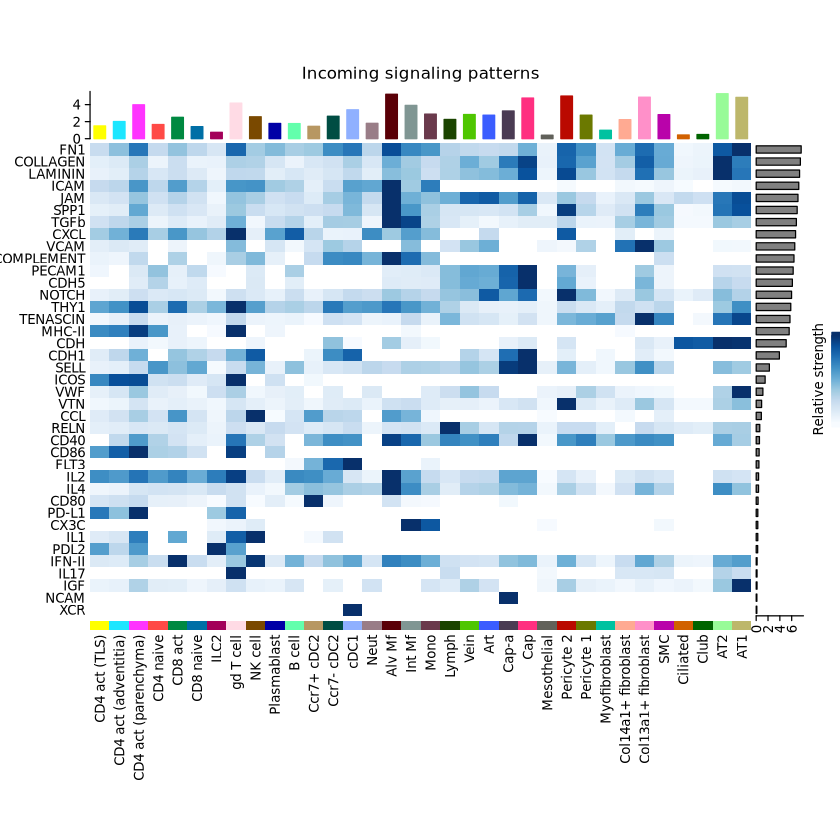

In [16]:
netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming", width=14, height = 10, color.heatmap = "Blues", color.use=celltype_palette_mapped)

### Plot incoming signals with custom plot showing only CD4 subsets as targets

In [21]:
#  customizing: netAnalysis_signalingRole_heatmap 

pattern <- "incoming"
slot.name = "netP"
# color.heatmap = "BuGn"
color.heatmap = "Blues"
# color.heatmap = rev("Spectral")
signaling=NULL
title = NULL
color.use = NULL
width = 2
height = 10
font.size = 8
font.size.title = 10
cluster.rows = FALSE
cluster.cols = FALSE

# ka add
targets.use = c('CD4 act (TLS)','CD4 act (adventitia)','CD4 act (parenchyma)')


object = cellchat
centr <- slot(object, slot.name)$centr
outgoing <- matrix(0, nrow = nlevels(object@idents), ncol = length(centr))
incoming <- matrix(0, nrow = nlevels(object@idents), ncol = length(centr))
dimnames(outgoing) <- list(levels(object@idents), names(centr))
dimnames(incoming) <- dimnames(outgoing)

# length of centr is equivalent to the number of signaling pathways 
for (i in 1:length(centr)) {
    outgoing[,i] <- centr[[i]]$outdeg
    incoming[,i] <- centr[[i]]$indeg
  }
# mat is transpose of incoming or outgoing, such that rows are signal pathways, and columns are cell types
  if (pattern == "outgoing") {
    mat <- t(outgoing)
    legend.name <- "Outgoing"
  } else if (pattern == "incoming") {
    mat <- t(incoming)
    legend.name <- "Incoming"
  } else if (pattern == "all") {
    mat <- t(outgoing+ incoming)
    legend.name <- "Overall"
  }
  if (is.null(title)) {
    title <- paste0(legend.name, " signaling patterns")
  } else {
    title <- paste0(paste0(legend.name, " signaling patterns"), " - ",title)
  }

# drop signaling pathway rows not in specified list, if specified 
  if (!is.null(signaling)) {
    mat1 <- mat[rownames(mat) %in% signaling, , drop = FALSE]
    mat <- matrix(0, nrow = length(signaling), ncol = ncol(mat))
    idx <- match(rownames(mat1), signaling)
    mat[idx[!is.na(idx)], ] <- mat1
    dimnames(mat) <- list(signaling, colnames(mat1))
  }

# row scale the matrix; rows are signals, so this scales a given signal across all cell types 
  mat.ori <- mat
  mat <- sweep(mat, 1L, apply(mat, 1, max), '/', check.margin = FALSE) # column scaling instead would be: mat <- sweep(mat, 2L, apply(mat, 2, max), '/', check.margin = FALSE)
  mat[mat == 0] <- NA

# KA add: drop receiver cell types not in targets.use -- AFTER scaling across pathways
if (!is.null(targets.use)) {
  mat1 <- mat[, colnames(mat) %in% targets.use, drop = FALSE]
  mat <- matrix(0, nrow = nrow(mat), ncol = length(targets.use))
  idx <- match(colnames(mat1), targets.use)
  mat[, idx[!is.na(idx)]] <- mat1
  dimnames(mat) <- list(rownames(mat1), targets.use)
}

 # KA add: remove signaling pathways that are entirely NA
    keep <- !apply(mat, 1, function(x) all(is.nan(x)))
    mat <- mat[keep, , drop = FALSE]
    # also drop these in the unscaled matrix
    mat.ori <- mat.ori[keep, , drop = FALSE]

if (is.null(color.use)) {
    color.use <- scPalette(length(colnames(mat)))
  }
  color.heatmap.use = grDevices::colorRampPalette((RColorBrewer::brewer.pal(n = 9, name = color.heatmap)))(100)

  df<- data.frame(group = colnames(mat)); rownames(df) <- colnames(mat)
  names(color.use) <- colnames(mat)

  if (min(mat, na.rm = T) == max(mat, na.rm = T)) {
    legend.break <- max(mat, na.rm = T)
  } else {
    legend.break <- c(round(min(mat, na.rm = T), digits = 1), round(max(mat, na.rm = T), digits = 1))
  }

    # KA add: cluster columns
    mat.clust <- mat
    mat.clust[!is.finite(mat.clust)] <- 0   # replaces NA, NaN, Inf, -Inf
    cluster_rows = hclust(dist(mat.clust, method = "euclidean"), method = "ward.D2")
                   
  ht1 = Heatmap(mat, col = color.heatmap.use, na_col = "white", name = "Relative strength",
                cluster_rows = cluster_rows,
                cluster_columns = cluster.rows,
                column_names_side = "top",
                show_column_dend = FALSE,
                show_row_dend = FALSE,
                row_names_side = "left",row_names_rot = 0,row_names_gp = gpar(fontsize = font.size),column_names_gp = gpar(fontsize = font.size),
                width = unit(width, "cm"), height = unit(height, "cm"),
                column_title = title,column_title_gp = gpar(fontsize = font.size.title),column_names_rot = 90,
                heatmap_legend_param = list(title_gp = gpar(fontsize = 8, fontface = "plain"),title_position = "leftcenter-rot",
                                            border = NA, at = legend.break,
                                            legend_height = unit(20, "mm"),labels_gp = gpar(fontsize = 8),grid_width = unit(2, "mm"))
  )
   # draw(ht1)

png 
  2

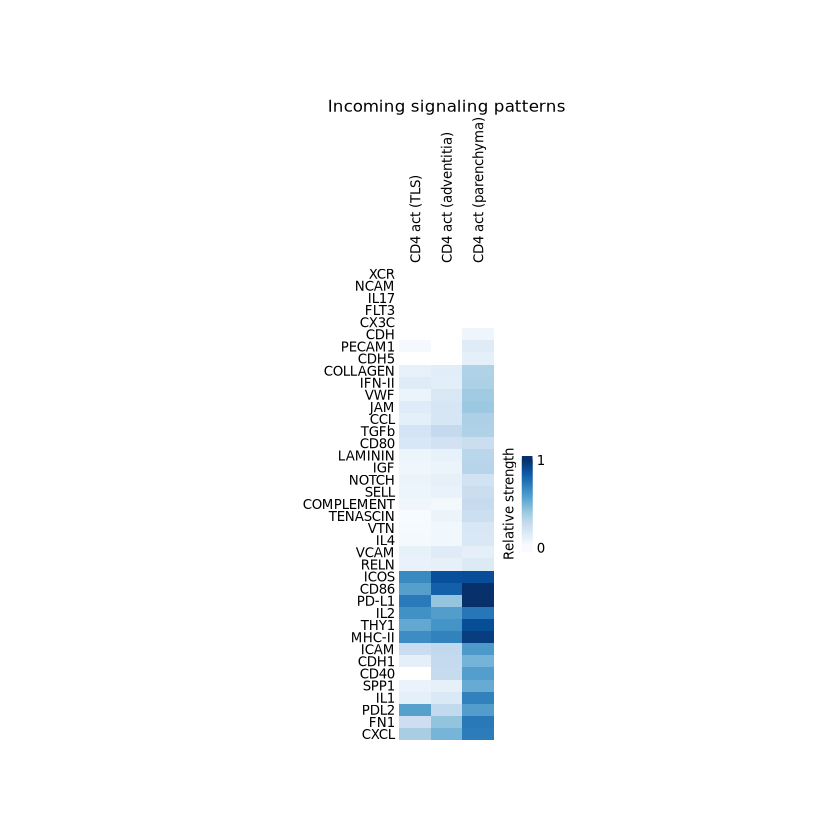

In [22]:
p <- draw(ht1)
pdf(file = file.path(plot_out_dir, "signaling_role_vertical_scaled-on-all-receivers_clusterrows.pdf"))
p
dev.off()

### Unpack individual pathways of interest

In [33]:
pairLR.use <- extractEnrichedLR(cellchat, signaling = "ICOS")
pairLR.use

interaction_name
<chr>
ICOSL_ICOS
ICOSL_CD28
ICOSL_CTLA4


[[1]]


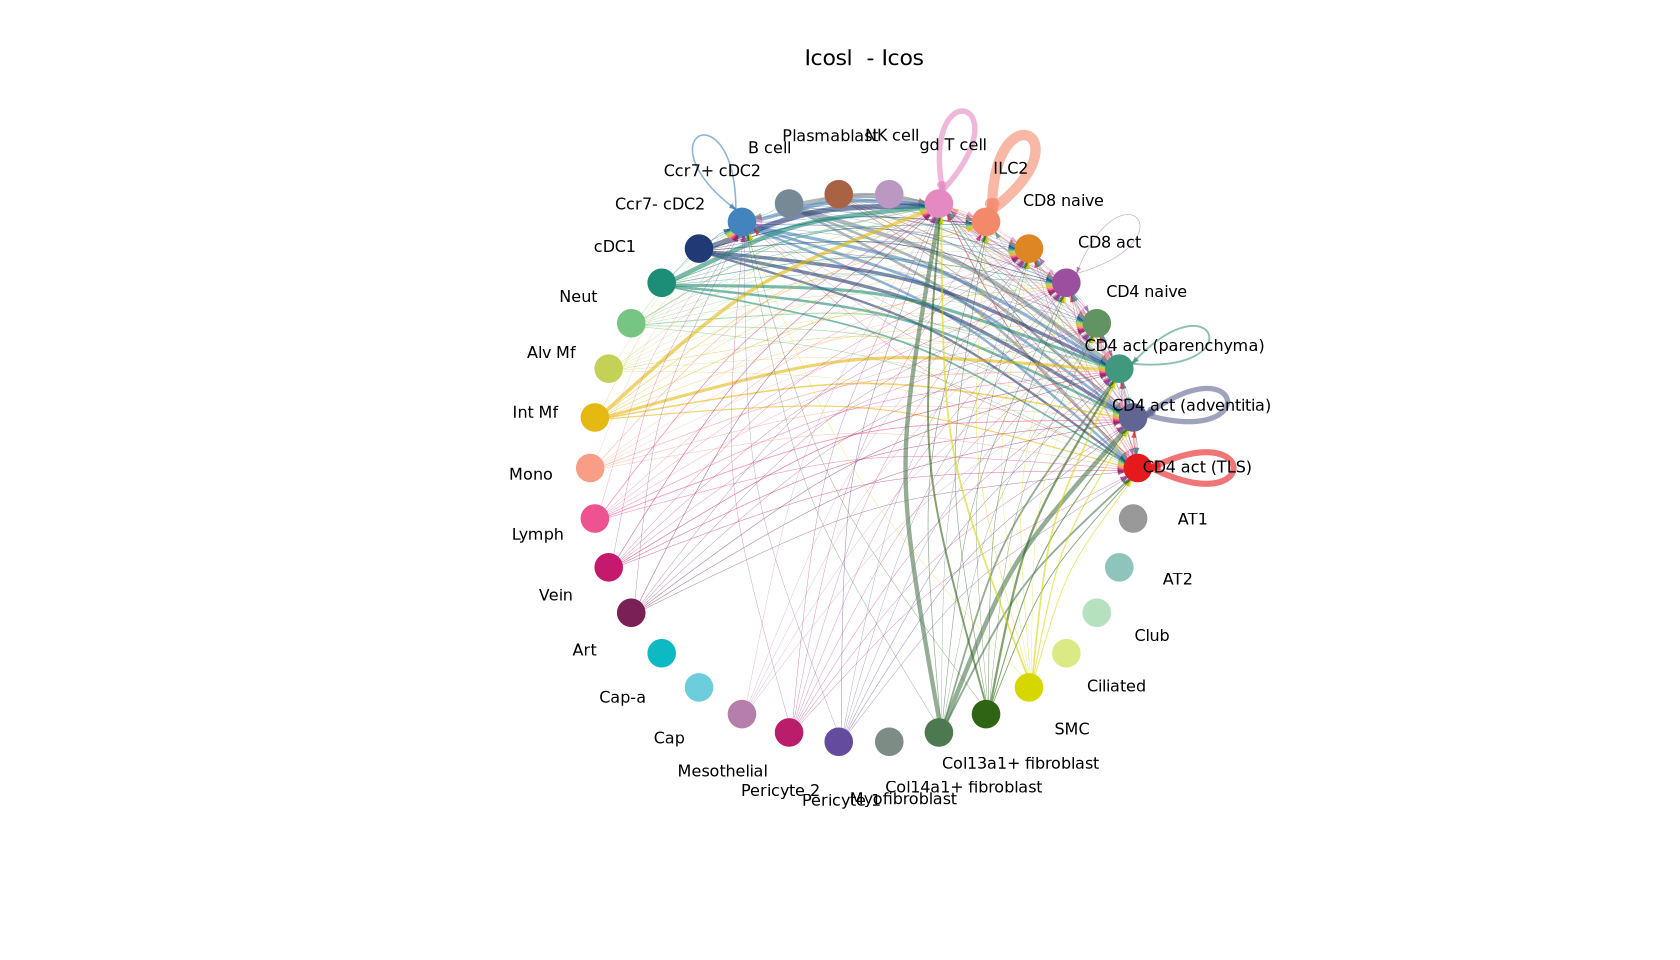

In [36]:
pathway = "ICOS"
pathway_df <- extractEnrichedLR(cellchat, signaling = pathway)
# single_interaction <- pathway_df[pathway_df$interaction_name == "CXCL16_CXCR6", , drop = FALSE]
single_interaction <- pathway_df[pathway_df$interaction_name == "ICOSL_ICOS", , drop = FALSE]

netVisual_individual(
  cellchat,
  signaling = pathway,          
  pairLR.use = single_interaction, 
  layout = "circle",
  # color.use = obj_palette
)

[[1]]


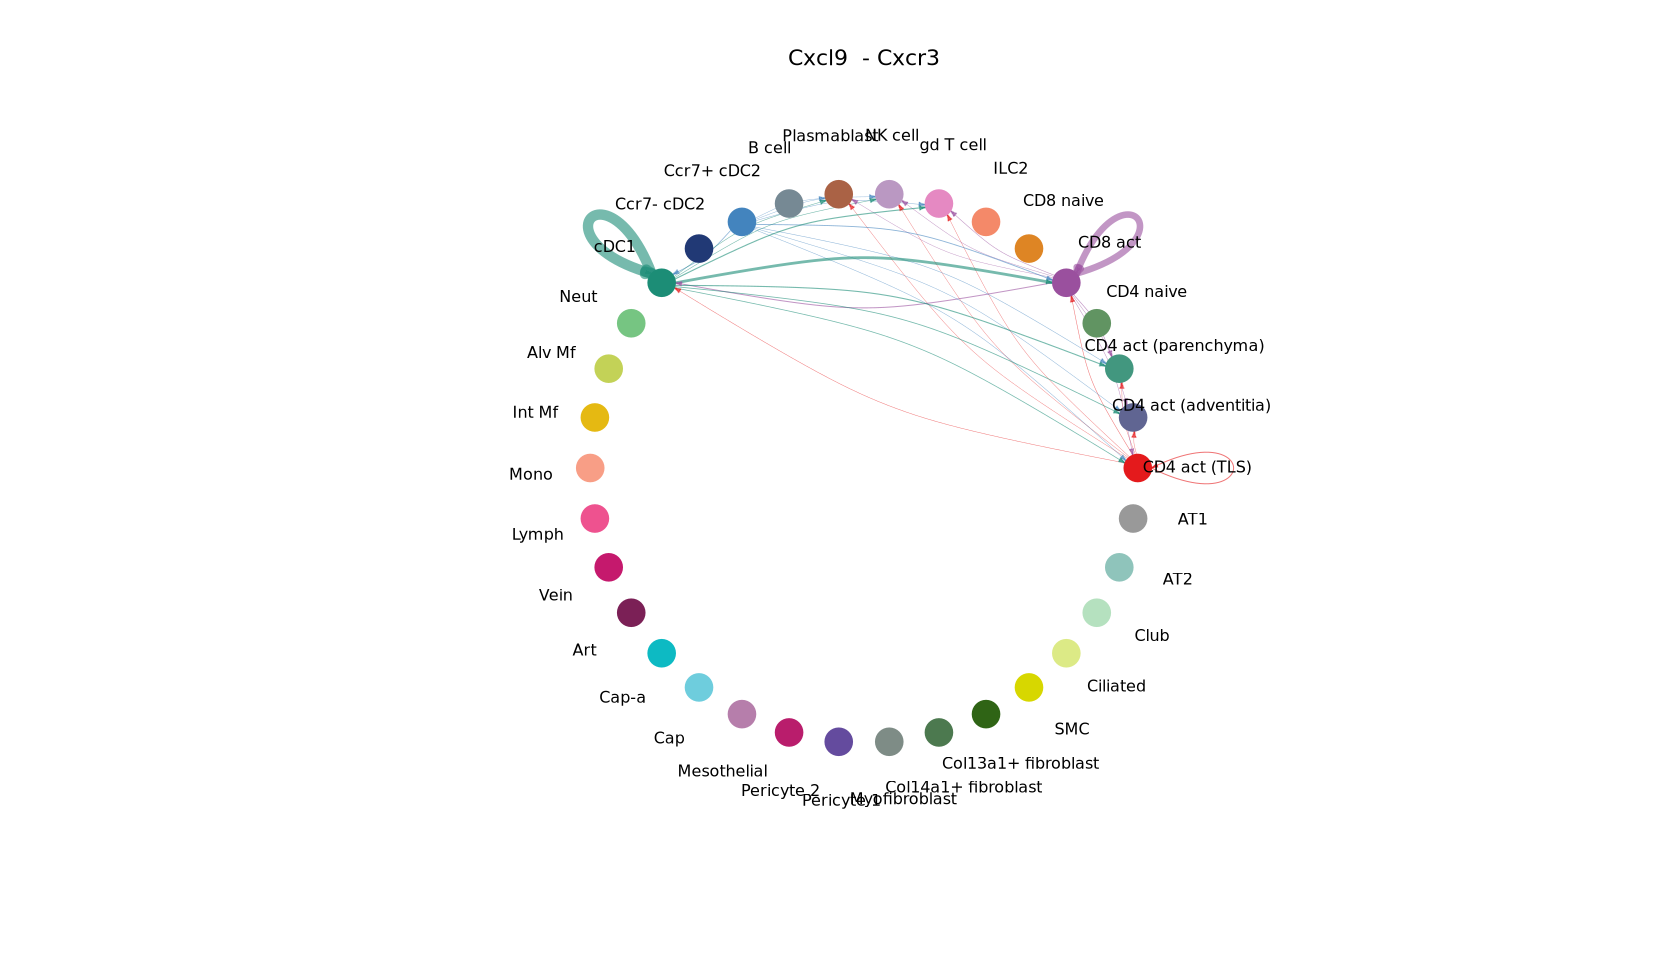

In [31]:
pathway = "CXCL"
pathway_df <- extractEnrichedLR(cellchat, signaling = pathway)
# single_interaction <- pathway_df[pathway_df$interaction_name == "CXCL16_CXCR6", , drop = FALSE]
single_interaction <- pathway_df[pathway_df$interaction_name == "CXCL9_CXCR3", , drop = FALSE]


netVisual_individual(
  cellchat,
  signaling = pathway,          
  pairLR.use = single_interaction, 
  layout = "circle",
  # color.use = obj_palette
)

Comparing communications on a single object 




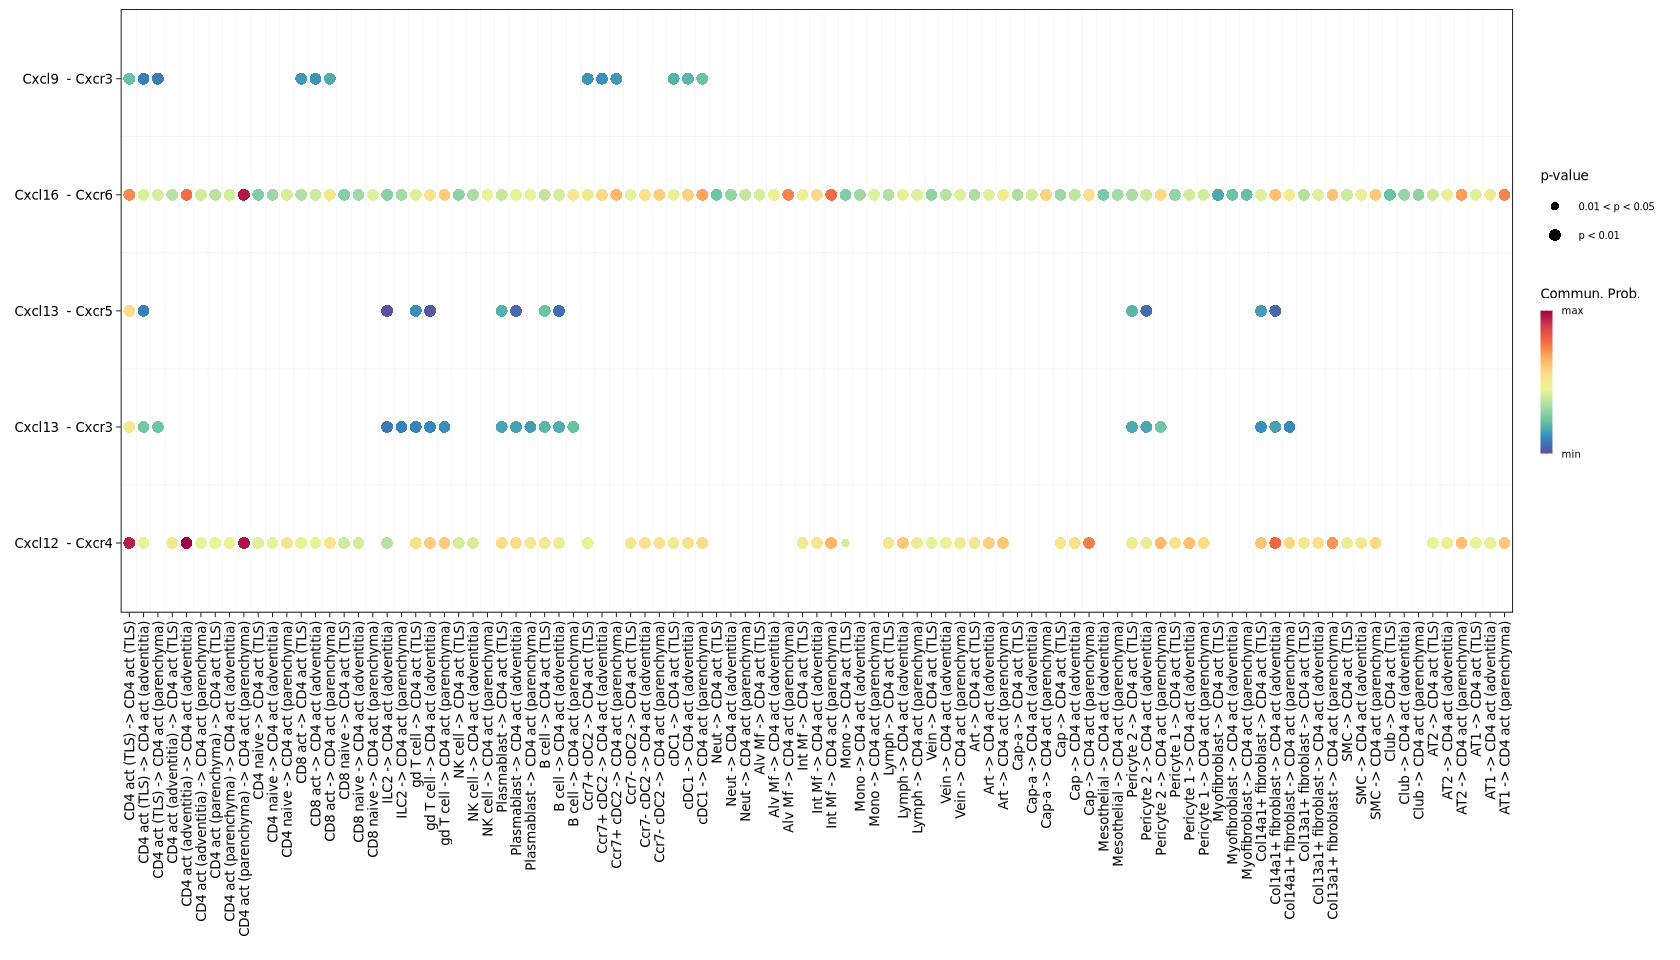

In [23]:
cd4_targets = c('CD4 act (parenchyma)', 'CD4 act (adventitia)', 'CD4 act (TLS)')
options(repr.plot.width = 14, repr.plot.height = 8)
netVisual_bubble(
  cellchat,
  # sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
  targets.use = cd4_targets,
  signaling = c("CXCL"),  
    # pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

In [ ]:
library(ComplexHeatmap)
library(RColorBrewer)
library(circlize)

netVisual_heatmap_targetsOnly <- function(object,
                                          sources.use = NULL,
                                          targets.use = NULL,
                                          signaling = NULL,
                                          pairLR.use = NULL,
                                          thresh = 0.05,
                                          # color.heatmap = "Spectral",
                                          color.heatmap = "BuGn",
                                          n.colors = 10,
                                          # direction = -1,
                                          direction = 1,
                                          font.size = 16,
                                          font.size.title = 10,
                                          title.name = NULL,
                                          cluster.rows = FALSE,
                                          cluster.cols = FALSE,
                                          row.order = NULL,
                                          return.data = FALSE) {


    # color setup
  color.heatmap = grDevices::colorRampPalette((RColorBrewer::brewer.pal(n = 9, name = color.heatmap)))(100)
    
  #--- get communication data
    if (is.null(pairLR.use)) {
        df.net <- subsetCommunication(object,
                                slot.name = "net",
                                sources.use = sources.use,
                                targets.use = targets.use,
                                signaling = signaling,
                                thresh = thresh)} 
    else{
        df.net <- subsetCommunication(object,
                        slot.name = "net",
                        sources.use = sources.use,
                        targets.use = targets.use,
                        pairLR.use = pairLR.use,
                        thresh = thresh)}      
    

  df.net.original <- df.net

  #--- filter to only selected targets
  df.net <- df.net[df.net$target %in% targets.use, , drop = FALSE]

  #--- drop nonsignificant
  df.net <- df.net[df.net$pval <= thresh, , drop = FALSE]

  if (nrow(df.net) == 0) stop("No significant interactions found for given targets")

  #--- row labels = sender + interaction
  df.net$row_label <- paste(df.net$source)

  #--- keep prob + pval for plotting
  df.net$prob[df.net$prob == 0] <- NA
  df.net$prob.original <- df.net$prob
  df.net$prob <- -1 / log(df.net$prob)

  #--- pivot into wide matrix
  mat <- reshape2::acast(df.net, row_label ~ target, value.var = "prob", fun.aggregate = mean)

  #--- color scale setup
  if (length(color.heatmap) == 1) {
    color.use <- tryCatch({
      RColorBrewer::brewer.pal(n = n.colors, name = color.heatmap)
    }, error = function(e) {
      scales::viridis_pal(option = color.heatmap, direction = -1)(n.colors)
    })
  } else {
    color.use <- color.heatmap
  }
  if (direction == -1) {
    color.use <- rev(color.use)
  }
  color.heatmap.use <- colorRampPalette(color.use)(100)

#--- enforce row order if provided
  if (!is.null(row.order)) {
    row.keep <- intersect(row.order, rownames(mat))
    mat <- mat[row.keep, , drop = FALSE]
  }

  #--- build heatmap
  ht <- Heatmap(mat,
                col = color.heatmap.use,
                na_col = "white",
                name = "Commun. Prob.",
                cluster_rows = cluster.rows, 
                show_row_dend = FALSE,
                cluster_columns=FALSE,
                row_names_gp = grid::gpar(fontsize = font.size),
                column_names_gp = grid::gpar(fontsize = font.size),
                column_title = title.name,
                column_title_gp = grid::gpar(fontsize = font.size.title),
                row_names_side = "left")

  draw(ht)

  if (return.data) {
    return(mat)
  } else {
    return(ht)
  }
}


In [ ]:
cd4_targets = c('CD4 act (parenchyma)', 'CD4 act (adventitia)', 'CD4 act (TLS)')
# pdf(file = file.path(plot_out_dir, "PDL2_senders_CD4_categories.pdf"), width=4, height=5)
netVisual_heatmap_targetsOnly(cellchat, 
                              # color.heatmap = "Spectral",
                              # direction = -1,
                              color.heatmap = "Blues",
                              direction = 1,
                                      signaling = c("CXCL"),
                                      # sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
                                      targets.use = cd4_targets,
                              cluster.rows = FALSE, 
                              # row.order = c('Ccr7+ cDC2', 'Alv Mf', 'Int Mf','Ccr7- cDC2', 'B cell' ),
                              return.data=FALSE)
# dev.off()